### Libraries

In [1]:
import os
import json
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
from Inference_Funcs_FMG import (
    load_data,
    plot_diagnostic,
    plot_posterior_distributions,
    plot_posterior_predictive,
    plot_pairplot
)
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes

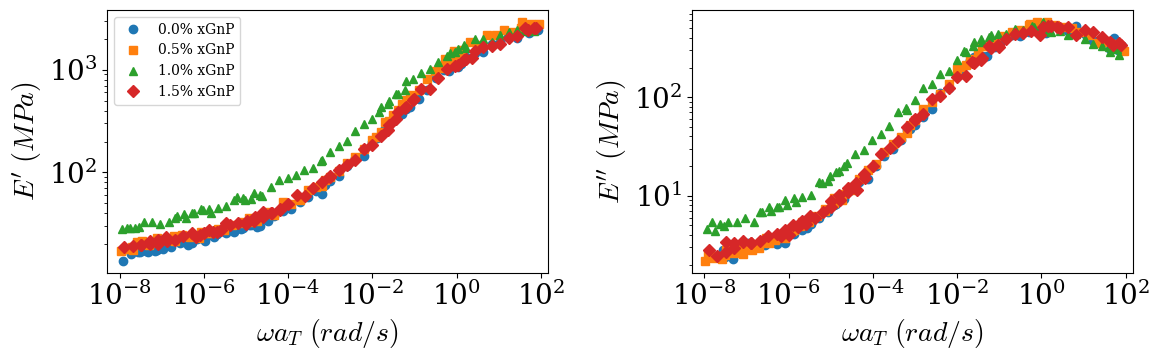

In [2]:
# ------------------------------------------------------------
# Set up argument parsing and load configuration and data
# ------------------------------------------------------------
# Load configuration and data
HS = 20
with open(f'../Configs/{HS}HSWF_FMG_Config.json', 'r') as config_file:
    config = json.load(config_file)

file_path = config['file_path']
sheet_name = config['sheet_name']
rows = config['rows']
cols_opt = config['cols_opt']
cols_GnP = config['cols_GnP']
GnPs = config['GnPs']
omega_limits = config['omega_limits']

rcParams_plot = config['rcParams_plot']

v_obs_Ep, v_obs_Epp, x_data, optimized_params_df = load_data(file_path, sheet_name, rows, cols_opt, cols_GnP, omega_limits, rcParams_plot)

param_list = ['E_c1', 'alpha_1', 'E_c2', 'alpha_2', 'sigma_Ep', 'sigma_Epp']
actual_param_name = [r'$E_{c_1}$', r'$\alpha_1$', r'$E_{c_2}$', r'$\alpha_2$',
                    r'$\sigma_{E^{\prime}}$', r'$\sigma_{E^{\prime\prime}}$']

# Load the inference data
idata_dict = {}
for GnP in GnPs:
    idata_dict[GnP] = az.from_netcdf(f"../Results/MCMC_FMG_{HS}HSWF/EpEpp_FMG_{HS}HS_{GnP}.nc")
df_mean_inference = pd.read_csv(f"../Results/MCMC_FMG_{HS}HSWF/Mean_Inference_{HS}HS_FMG.csv")
idata_mean_dict = df_mean_inference.set_index('GnP').to_dict(orient='index')

df_std_inference = pd.read_csv(f"../Results/MCMC_FMG_{HS}HSWF/std_Inference_{HS}HS_FMG.csv")
idata_std_dict = df_std_inference.set_index('GnP').to_dict(orient='index')

df_map_estimate = pd.read_csv(f"../Results/MCMC_FMG_{HS}HSWF/Map_Estimate_{HS}HS_FMG.csv")
map_estimate_dict = df_map_estimate.set_index('GnP').to_dict(orient='index')

df_error_measures = pd.read_csv(f"../Results/MCMC_FMG_{HS}HSWF/Error_Measures_{HS}HS_FMG.csv")
error_measures_dict = df_error_measures.set_index('GnP').to_dict(orient='index')

optimized_params_df['GnP'] = ['0.0GnP', '0.5GnP', '1.0GnP', '1.5GnP']
optimized_params_dict = optimized_params_df.set_index('GnP').to_dict(orient='index')

# Plot settings
plt.rcParams.update({
    'font.size': rcParams_plot['font.size'],
    'axes.labelsize': rcParams_plot['axes.labelsize'],
    'xtick.labelsize': rcParams_plot['xtick.labelsize'],
    'ytick.labelsize': rcParams_plot['ytick.labelsize'],
    'legend.fontsize': rcParams_plot['legend.fontsize'],
    'axes.titlesize': rcParams_plot['axes.titlesize'],
    'font.family': rcParams_plot['font.family'],
    'mathtext.fontset': rcParams_plot['mathtext.fontset'],
    'mathtext.rm': rcParams_plot['mathtext.rm'],
    'mathtext.it': rcParams_plot['mathtext.it'],
    'mathtext.bf': rcParams_plot['mathtext.bf']
})

In [3]:
v_obs_Ep_synthetic = np.zeros((300, 4))
v_obs_Epp_synthetic = np.zeros((300, 4))
x_obs_synthetic = np.zeros((300, 4))
i = 0
for GnP in GnPs:
    noise_Ep = np.random.normal(loc=1.0, scale=0.050, size=len(x_data[GnP]))
    noise_Epp = np.random.normal(loc=1.0, scale=0.050, size=len(x_data[GnP]))
    v_obs_Ep_synthetic[0:len(noise_Ep), i] = v_obs_Ep[GnP] * noise_Ep
    v_obs_Epp_synthetic[0:len(noise_Epp), i] = v_obs_Epp[GnP] * noise_Epp
    x_obs_synthetic[0:len(x_data[GnP]), i] = x_data[GnP]
    i += 1

v_obs_Ep_synthetic_df = pd.DataFrame(v_obs_Ep_synthetic, columns=GnPs, )
v_obs_Epp_synthetic_df = pd.DataFrame(v_obs_Epp_synthetic, columns=GnPs)
x_obs_synthetic_df = pd.DataFrame(x_obs_synthetic, columns=GnPs)

v_obs_Ep_synthetic_df.to_csv(f"v_obs_Ep_synthetic_{HS}.csv", index=False)
v_obs_Epp_synthetic_df.to_csv(f"v_obs_Epp_synthetic_{HS}.csv", index=False)
x_obs_synthetic_df.to_csv(f"x_obs_synthetic_{HS}.csv", index=False)

# plt.loglog(x_data['0.5GnP'], v_obs_Ep['0.5GnP'], 'o', label='0.0GnP')
# plt.loglog(x_data['0.5GnP'], v_obs_Ep_synthetic['0.5GnP'], 'x', label='0.0GnP Synthetic')

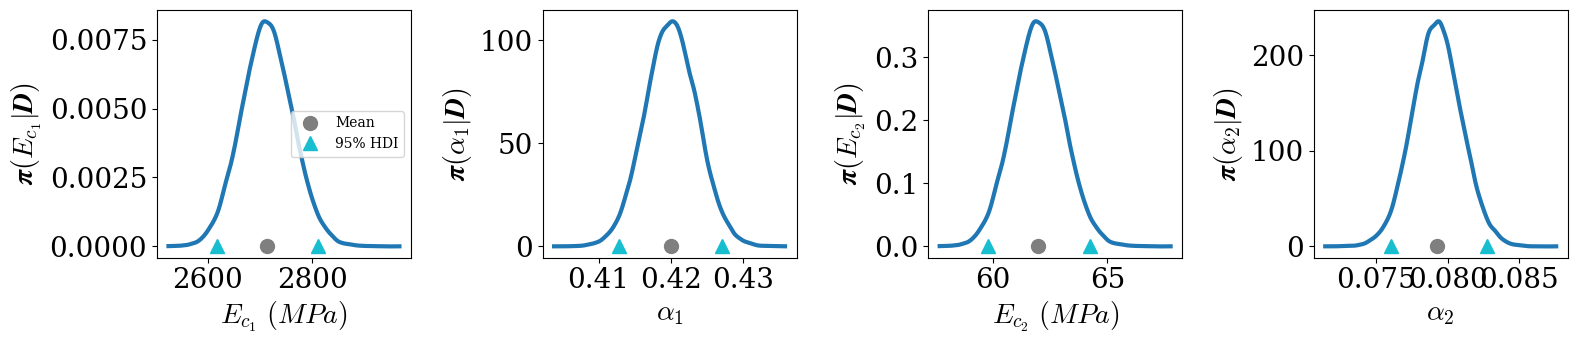

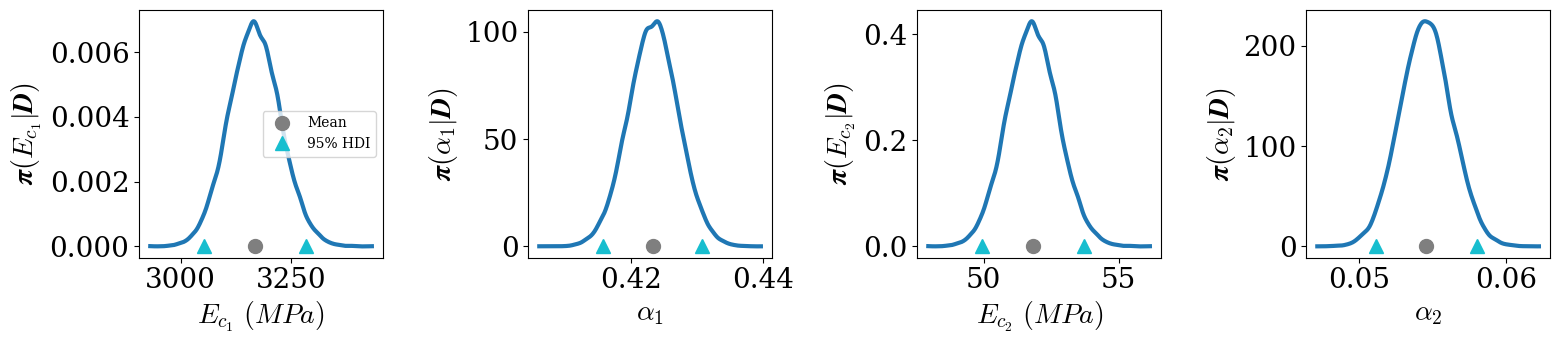

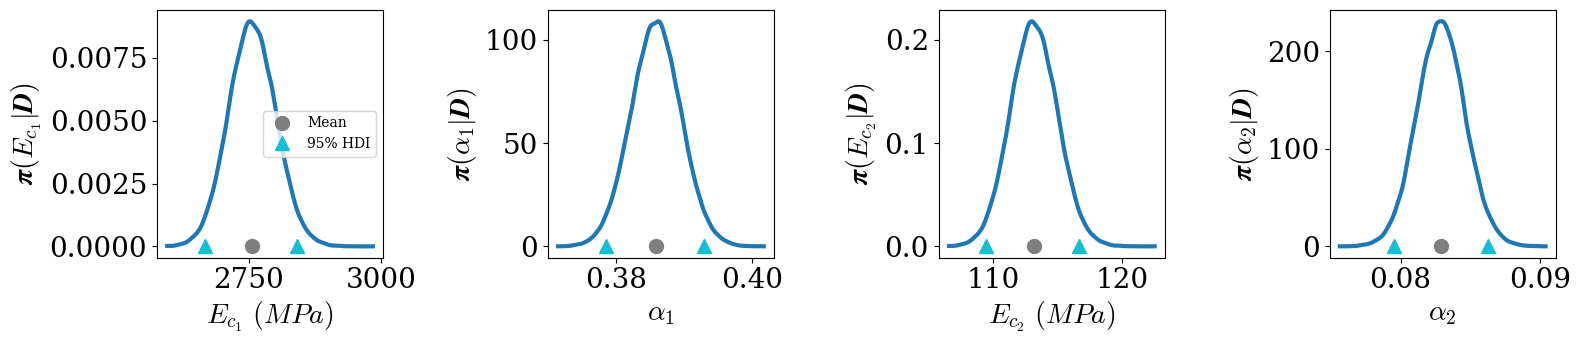

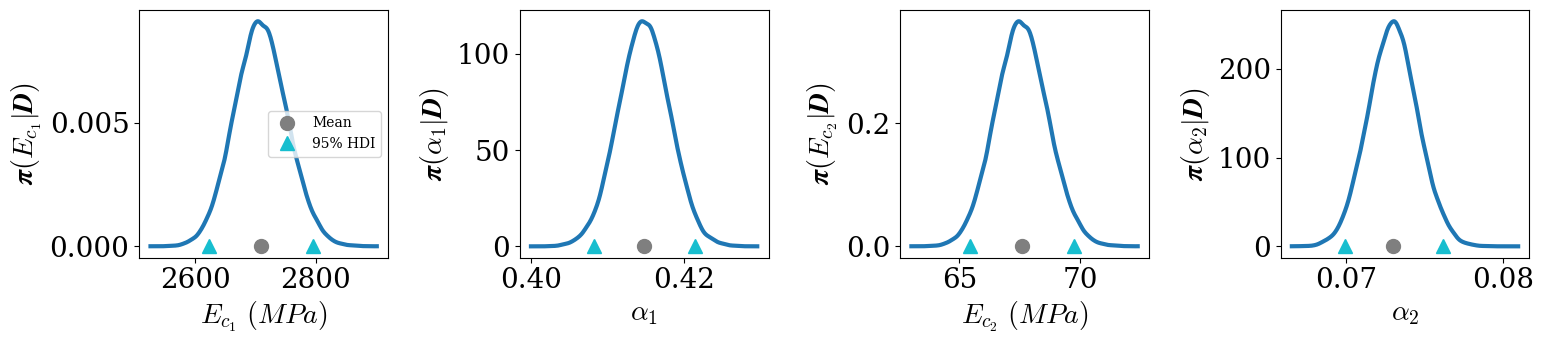

In [3]:
# --------------------------------------------------
# Posterior distribution plots
# --------------------------------------------------
for GnP_idx in range(len(GnPs)):
    plt_set = {
        "savefig_path": f"{file_path['file_path_save']}/Posterior_FMG_{HS}HS_{GnPs[GnP_idx]}.png"
    }
    os.makedirs(os.path.dirname(file_path['file_path_save']), exist_ok=True)
    plot_posterior_distributions(
        idata_dict[GnPs[GnP_idx]], idata_mean_dict[GnPs[GnP_idx]],
        param_list, actual_param_name, plt_set, rcParams_plot
    )

hdi_prob = 0.95
model_param_hdi_dict = {}
for GnP in GnPs:
    idata = idata_dict[GnP]
    model_param_hdi_dict[GnP] = {
        'E_c1': az.hdi(idata.posterior['E_c1'].values.flatten(), hdi_prob=hdi_prob),
        'E_c2': az.hdi(idata.posterior['E_c2'].values.flatten(), hdi_prob=hdi_prob),
        'alpha_1': az.hdi(idata.posterior['alpha_1'].values.flatten(), hdi_prob=hdi_prob),
        'alpha_2': az.hdi(idata.posterior['alpha_2'].values.flatten(), hdi_prob=hdi_prob)
    }

wide_rows = []

for GnP, params in model_param_hdi_dict.items():
    row = {'GnP': GnP}
    for param_name, hdi_vals in params.items():
        row[f"{param_name}_lower"] = hdi_vals[0]
        row[f"{param_name}_upper"] = hdi_vals[1]
    wide_rows.append(row)

df_hdi_wide = pd.DataFrame(wide_rows)
df_hdi_wide.to_csv(f"{file_path['file_path_save']}/Model_Param_HDI_FMG_{HS}HS.csv", index=False)

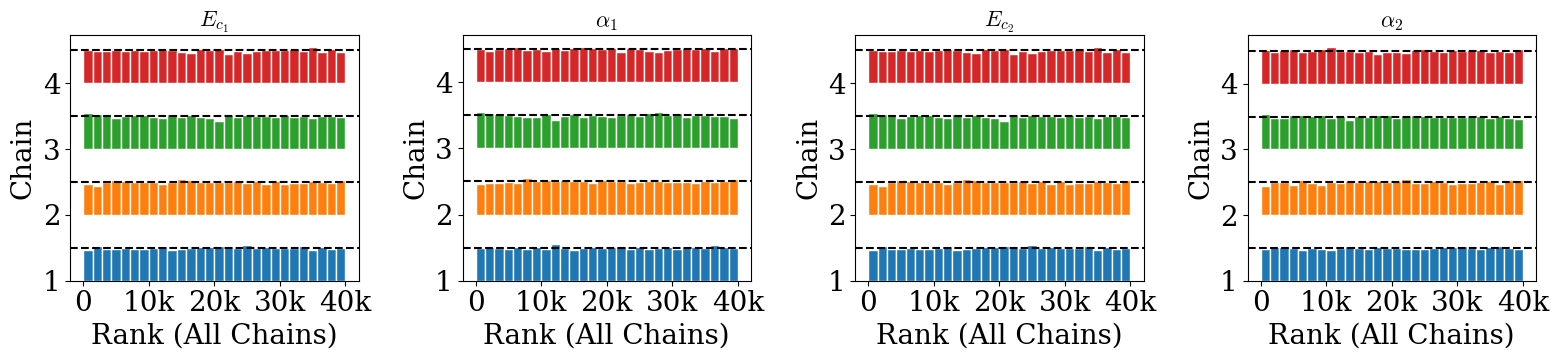

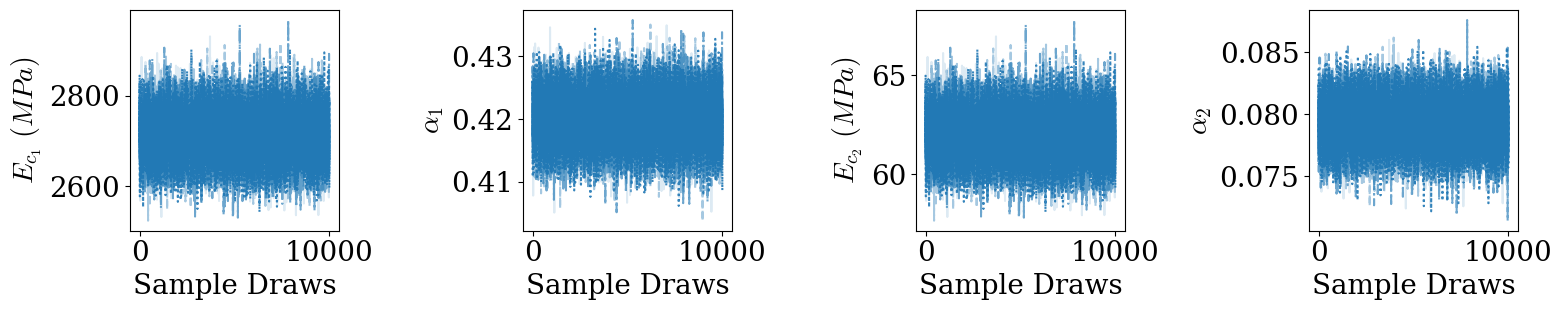

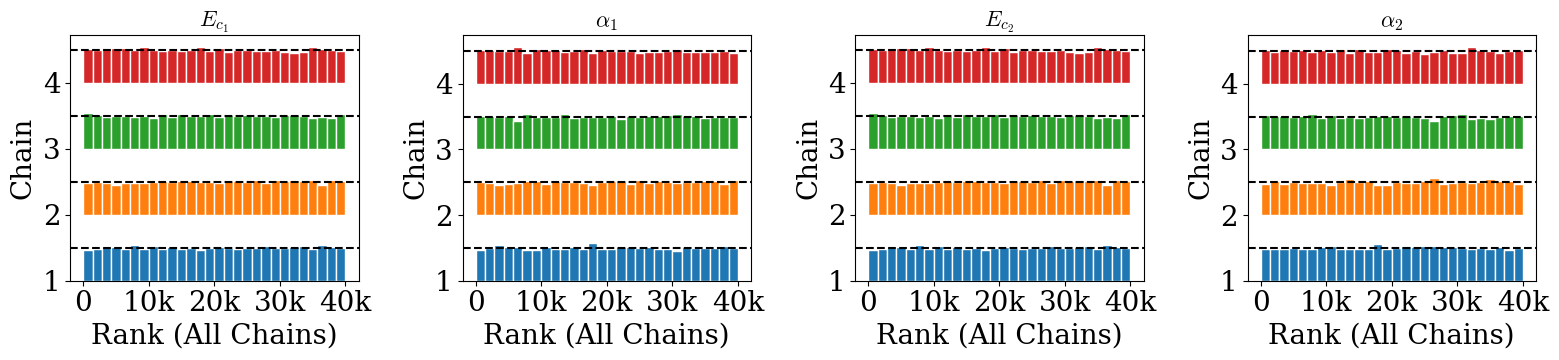

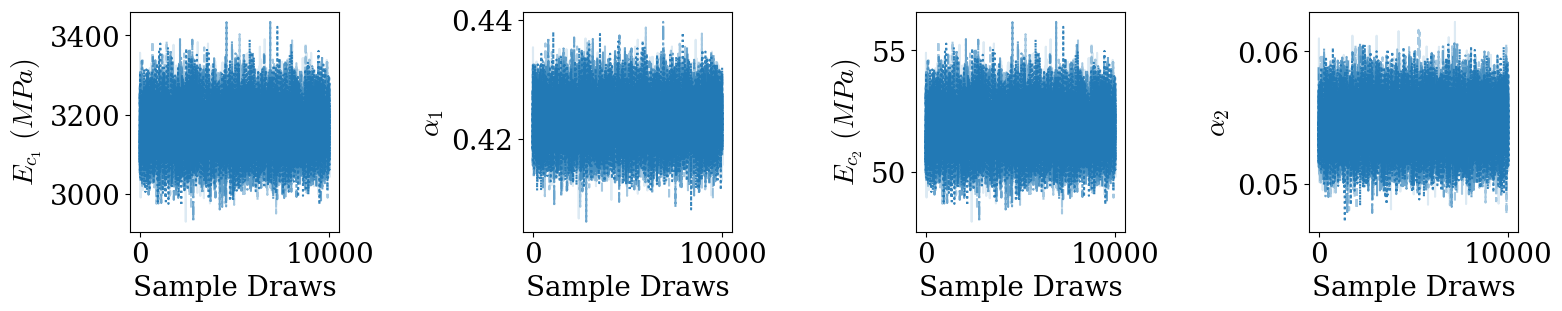

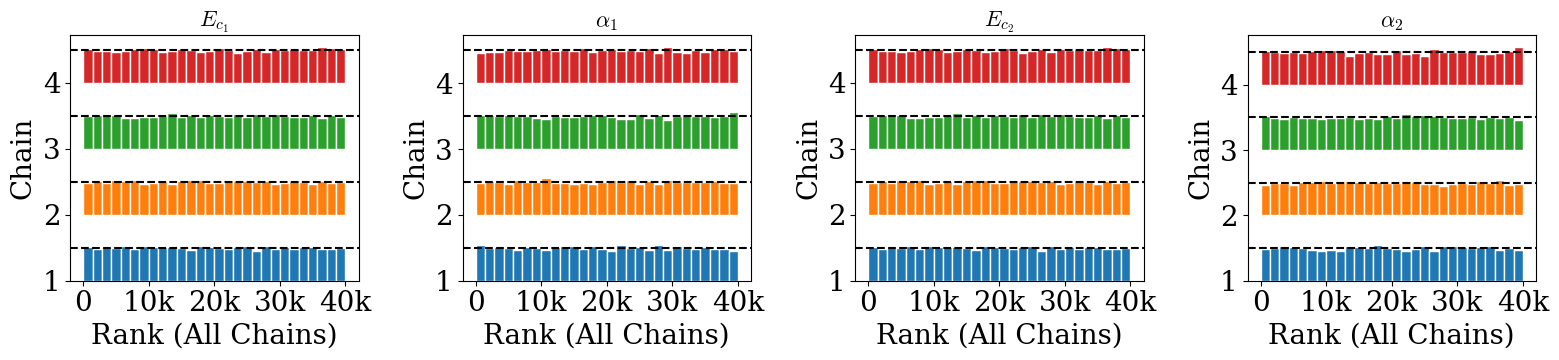

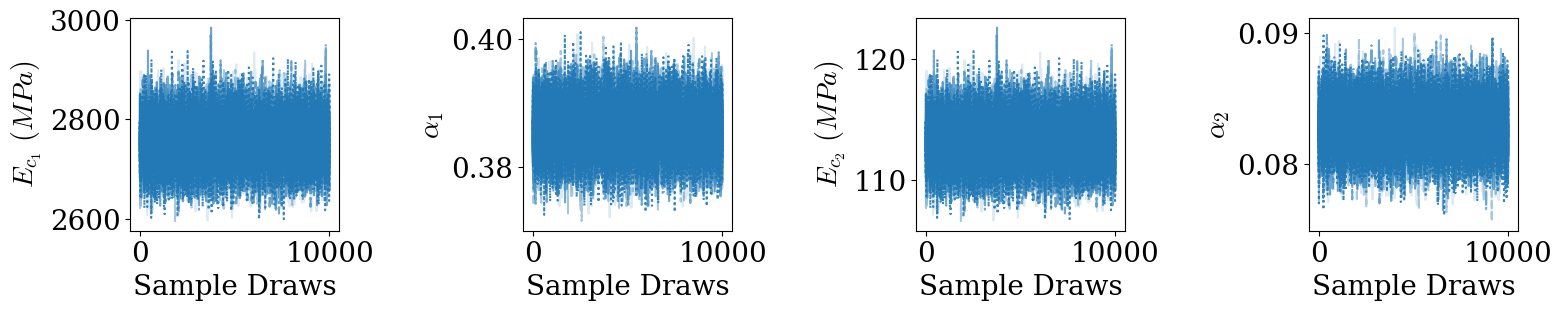

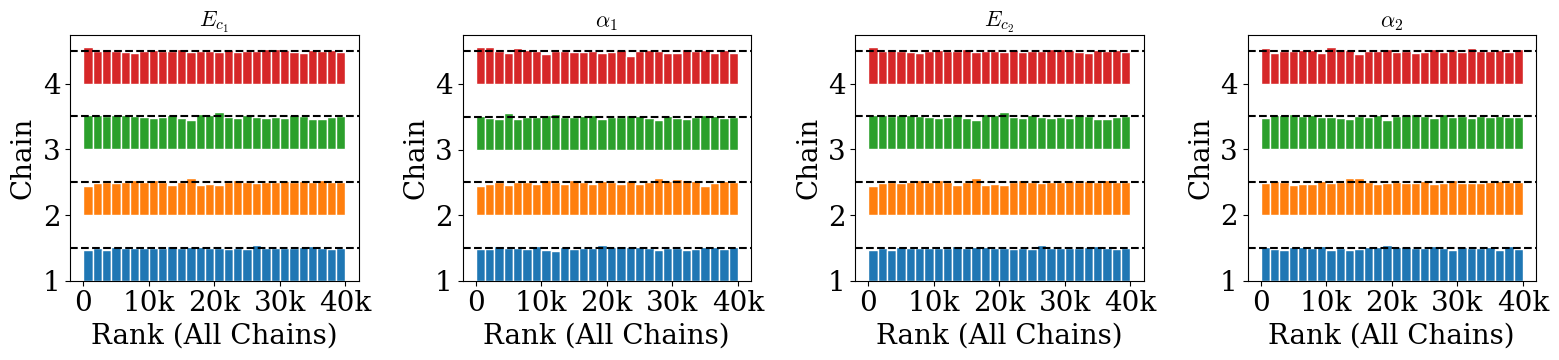

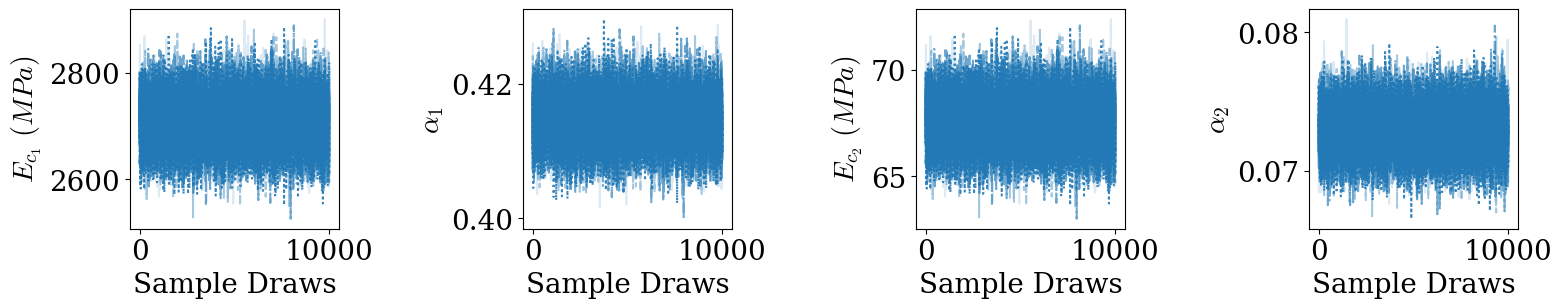

In [4]:
# --------------------------------------------------
# Rank plots and trace plots
# --------------------------------------------------
var_names = param_list[:4]
xticks = np.linspace(0, config['hyperparams']['draws'] * config['hyperparams']['chains'], 5).tolist()
xtickslabels = ['0', '10k', '20k', '30k', '40k']
for GnP in idata_dict.keys():
    idata = idata_dict[GnP]
    plt_set = {
        "savefig_path_rank": f"{file_path['file_path_save']}/Rank_Plots_FMG_{HS}HS_{GnP}.png",
        "savefig_path_trace": f"{file_path['file_path_save']}/Trace_Plots_FMG_{HS}HS_{GnP}.png"
    }
    plot_diagnostic(idata, var_names, xticks, xtickslabels, plt_set, rcParams_plot)

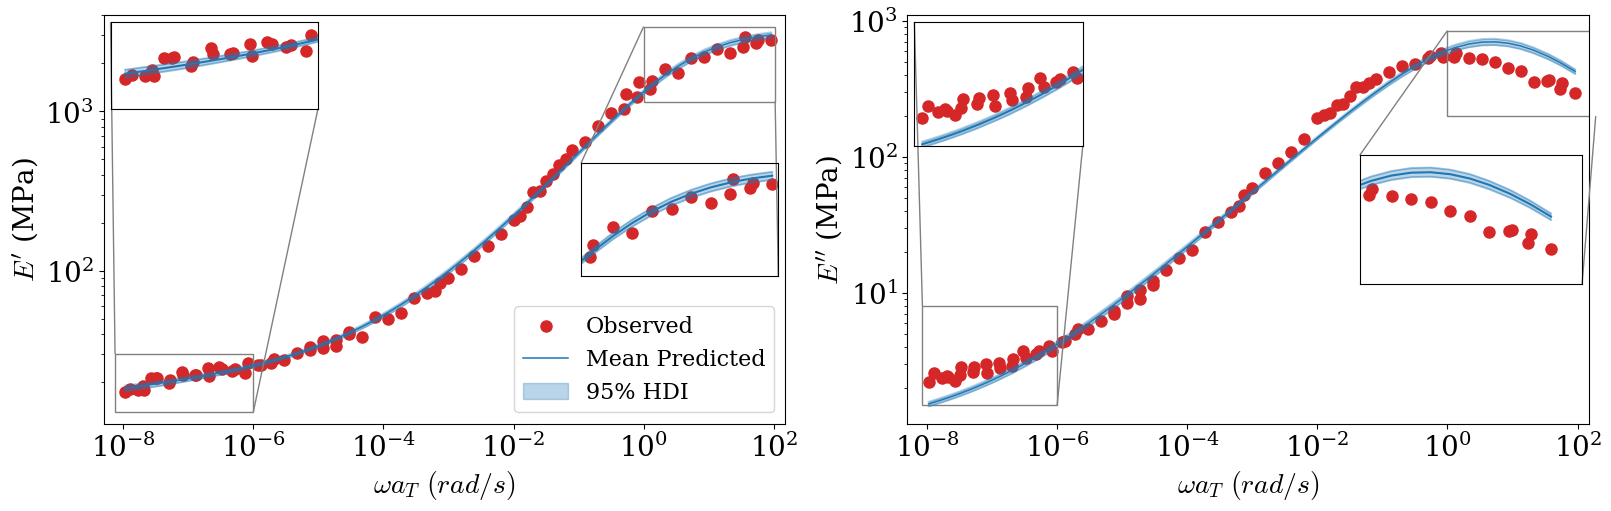

In [5]:
# --------------------------------------------------
# Zoomed-in plots
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
axes = axes.flatten()

GnP_idx = 1
Ep_pred = idata_dict[GnPs[GnP_idx]].posterior["Ep_pred"]
Ep_pred_mean = Ep_pred.mean(dim=["draw", "chain"])
Epp_pred = idata_dict[GnPs[GnP_idx]].posterior["Epp_pred"]
Epp_pred_mean = Epp_pred.mean(dim=["draw", "chain"])

# Plot for Ep_pred
axes[0].scatter(x_data[GnPs[GnP_idx]], v_obs_Ep[GnPs[GnP_idx]], label='Observed', marker='o', s=64, color='C3')
axes[0].plot(x_data[GnPs[GnP_idx]], Ep_pred_mean, label='Mean Predicted', linestyle='-', color='C0', linewidth=1.1)
az.plot_hdi(
    x_data[GnPs[GnP_idx]],
    Ep_pred,
    hdi_prob=0.95,
    smooth=False,
    plot_kwargs={'color': 'C0', 'alpha': 0.3},
    fill_kwargs={'color': 'C0', 'alpha': 0.3, 'label': r'95% HDI'},
    ax=axes[0]
)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"$\omega a_T \ (rad/s)$")
axes[0].set_ylabel(r"$E^{\prime}$ (MPa)")
axes[0].set_xlim([0.5*1e-8, 1.5*1e2])
axes[0].set_xticks([1e-8, 1e-6, 1e-4, 1e-2, 1e0, 1e2])
axes[0].set_ylim([1.1e1, 4e3])
axes[0].legend(fontsize=16, loc='lower right')

# First inset for Ep_pred
axins1 = zoomed_inset_axes(axes[0], zoom=1.5, loc='upper left')
axins1.loglog(x_data[GnPs[GnP_idx]], Ep_pred_mean, color='C0')
axins1.scatter(x_data[GnPs[GnP_idx]], v_obs_Ep[GnPs[GnP_idx]], color='C3', s=64)
az.plot_hdi(
    x_data[GnPs[GnP_idx]],
    Ep_pred,
    hdi_prob=0.95,
    smooth=False,
    plot_kwargs={'color': 'C0', 'alpha': 0.3},
    fill_kwargs={'color': 'C0', 'alpha': 0.3},
    ax=axins1
)
if HS == 20:
    x1, x2 = 0.75e-8, 1e-6
    y1, y2 = 13, 30
elif HS == 30:
    x1, x2 = 1e-8, 1e-6
    y1, y2 = 100, 200
else:
    x1, x2 = 1e-8, 1e-6
    y1, y2 = 200, 500
axins1.set_xlim(x1, x2)
axins1.set_ylim(y1, y2)
axins1.xaxis.set_visible(False)
axins1.yaxis.set_visible(False)
mark_inset(axes[0], axins1, loc1=2, loc2=4, fc="none", ec="0.5")

# Second inset for Ep_pred
axins2 = zoomed_inset_axes(axes[0], zoom=1.5, loc='center right')
axins2.loglog(x_data[GnPs[GnP_idx]], Ep_pred_mean, color='C0')
axins2.scatter(x_data[GnPs[GnP_idx]], v_obs_Ep[GnPs[GnP_idx]], color='C3', s=64)
az.plot_hdi(
    x_data[GnPs[GnP_idx]],
    Ep_pred,
    hdi_prob=0.95,
    smooth=False,
    plot_kwargs={'color': 'C0', 'alpha': 0.3},
    fill_kwargs={'color': 'C0', 'alpha': 0.3},
    ax=axins2
)

if HS == 20:
    x1, x2 = 1, 105
    y1, y2 = 1150, 3400
elif HS == 30:
    x1, x2 = 0.1, 20
    y1, y2 = 1250, 3400
else:
    x1, x2 = 1, 90
    y1, y2 = 1250, 3400

axins2.set_xlim(x1, x2)
axins2.set_ylim(y1, y2)
axins2.xaxis.set_visible(False)
axins2.yaxis.set_visible(False)
mark_inset(axes[0], axins2, loc1=2, loc2=4, fc="none", ec="0.5")

# Epp
axes[1].scatter(x_data[GnPs[GnP_idx]], v_obs_Epp[GnPs[GnP_idx]], label='Observed', marker='o', s=64, color='C3')
axes[1].plot(x_data[GnPs[GnP_idx]], Epp_pred_mean, label='Mean Predicted', linestyle='-', color='C0', linewidth=1.1)
az.plot_hdi(
    x_data[GnPs[GnP_idx]],
    Epp_pred,
    hdi_prob=0.95,
    smooth=False,
    plot_kwargs={'color': 'C0', 'alpha': 0.3},
    fill_kwargs={'color': 'C0', 'alpha': 0.3},
    ax=axes[1]
)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel(r"$\omega a_T \ (rad/s)$")
axes[1].set_ylabel(r"$E^{\prime\prime}$ (MPa)")
axes[1].set_xlim([0.5*1e-8, 1.5*1e2])
axes[1].set_xticks([1e-8, 1e-6, 1e-4, 1e-2, 1e0, 1e2])
axes[1].set_ylim([1.1e0, 1.1e3])

# First inset for Epp_pred
axins3 = zoomed_inset_axes(axes[1], zoom=1.5, loc='center right')
axins3.loglog(x_data[GnPs[GnP_idx]], Epp_pred_mean, color='C0')
axins3.scatter(x_data[GnPs[GnP_idx]], v_obs_Epp[GnPs[GnP_idx]], color='C3', s=64)
az.plot_hdi(
    x_data[GnPs[GnP_idx]],
    Epp_pred,
    hdi_prob=0.95,
    smooth=False,
    plot_kwargs={'color': 'C0', 'alpha': 0.3},
    fill_kwargs={'color': 'C0', 'alpha': 0.3},
    ax=axins3
)
if HS == 20:
    x1, x2 = 1, 190
    y1, y2 = 200, 850
elif HS == 30:
    x1, x2 = 0.2, 25
    y1, y2 = 200, 850
else:
    x1, x2 = 1, 90
    y1, y2 = 150, 750
axins3.set_xlim(x1, x2)
axins3.set_ylim(y1, y2)
axins3.xaxis.set_visible(False)
axins3.yaxis.set_visible(False)
mark_inset(axes[1], axins3, loc1=2, loc2=4, fc="none", ec="0.5")

# Second inset for Epp_pred
axins4 = zoomed_inset_axes(axes[1], zoom=1.25, loc='upper left')

axins4.loglog(x_data[GnPs[GnP_idx]], Epp_pred_mean, color='C0')
axins4.scatter(x_data[GnPs[GnP_idx]], v_obs_Epp[GnPs[GnP_idx]], color='C3', s=64)
az.plot_hdi(
    x_data[GnPs[GnP_idx]],
    Epp_pred,
    hdi_prob=0.95,
    smooth=False,
    plot_kwargs={'color': 'C0', 'alpha': 0.3},
    fill_kwargs={'color': 'C0', 'alpha': 0.3},
    ax=axins4
)
if HS == 20:
    x1, x2 = 0.85e-8, 1e-6
    y1, y2 = 1.5, 8
elif HS == 30:
    x1, x2 = 0.85e-8, 1e-6
    y1, y2 = 8, 30
else:
    x1, x2 = 0.75e-8, 1e-6
    y1, y2 = 15, 50

axins4.set_xlim(x1, x2)
axins4.set_ylim(y1, y2)
axins4.xaxis.set_visible(False)
axins4.yaxis.set_visible(False)
mark_inset(axes[1], axins4, loc1=2, loc2=4, fc="none", ec="0.5")

plt.show()

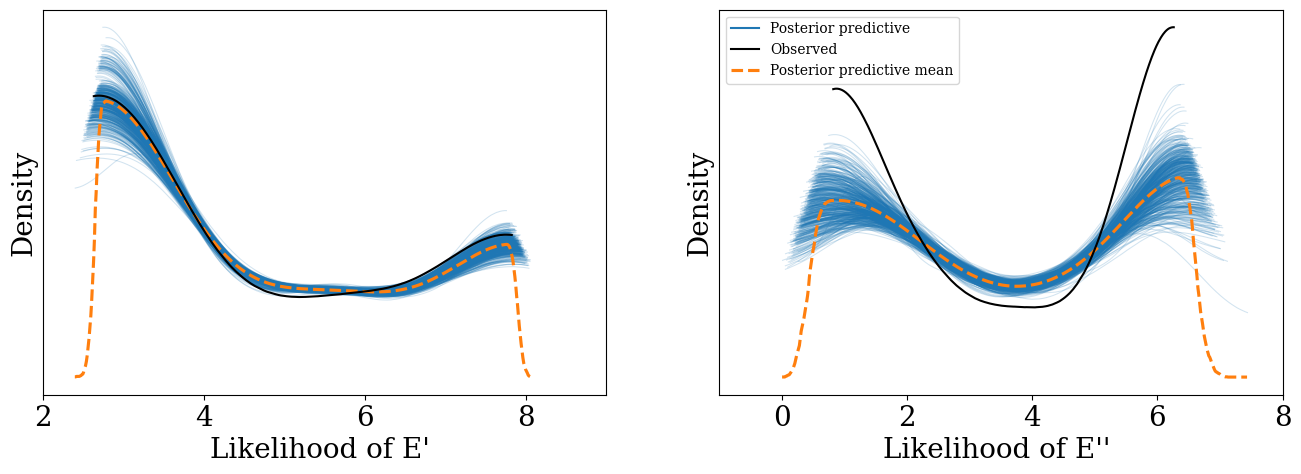

In [6]:
# --------------------------------------------------
# Plot posterior predictive
# --------------------------------------------------
GnP_idx = 0

if HS == 20: 
    range1 = [2, 9]
    range2 = [-1, 8]
elif HS == 30:
    range1 = [4.5, 8.5]
    range2 = [2, 6.5]
else:
    range1 = [5, 8.5]
    range2 = [2.5, 6.5]

plot_posterior_predictive(idata_dict[GnPs[GnP_idx]], range1, range2, rcParams_plot)

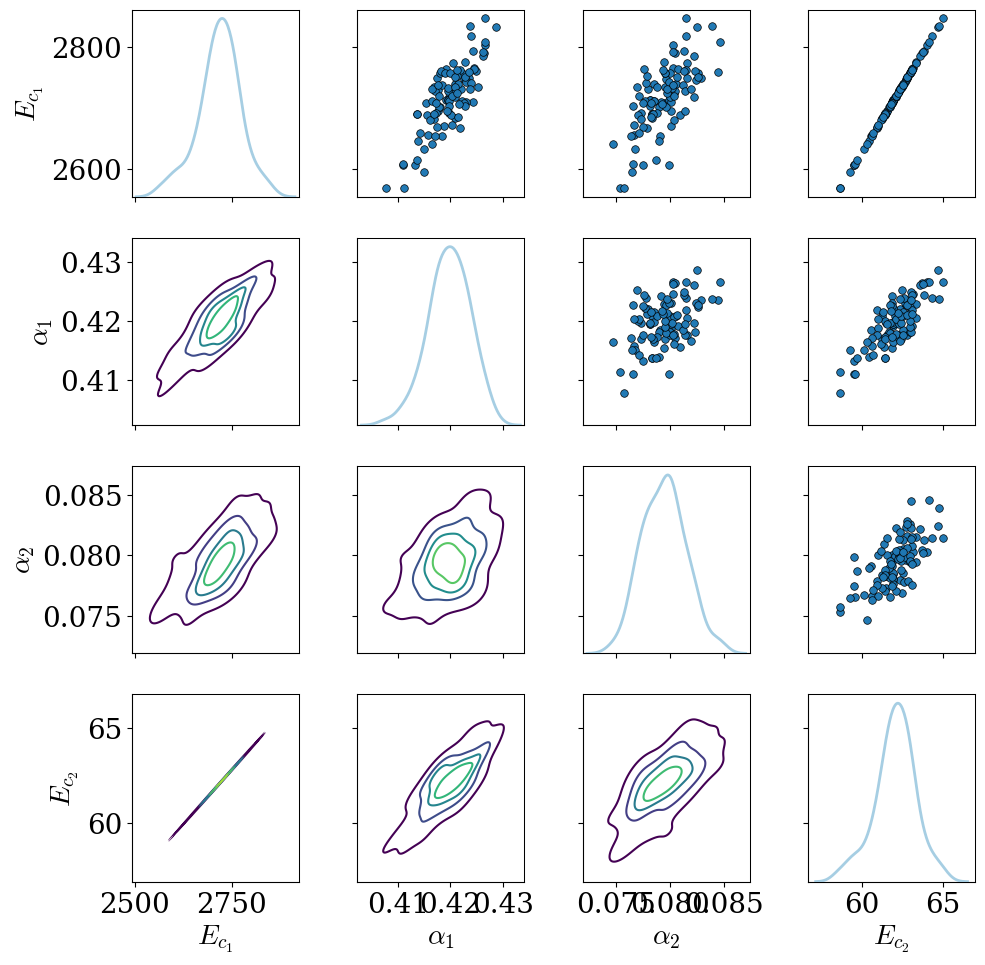

In [7]:
# --------------------------------------------------
# Pairplots
# --------------------------------------------------
plot_pairplot(idata_dict[GnPs[0]], ['E_c1', 'alpha_1', 'alpha_2', 'E_c2'], 100, rcParams_plot)